# Limpeza de Dados em Python
Este notebook demonstra técnicas comuns de limpeza de dados usando Python, pandas e numpy. Vamos explorar:

Identificação de valores ausentes

Tratamento de valores ausentes

Identificação de duplicatas

Remoção de duplicatas

Outras técnicas de limpeza básicas

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1 - Carregando dados

In [2]:
# Carregando os dados
df = pd.read_csv('dados_problema.csv')
print("Formato do DataFrame:", df.shape)
df.head()

Formato do DataFrame: (10, 6)


,id,nome,idade,salario,departamento,data_contratacao
0,1,João Silva,32.0,4500.0,TI,2020-01-15
1,2,Maria Santos,28.0,3800.0,Marketing,2019-06-20
2,3,João Silva,32.0,4500.0,TI,2020-01-15
3,4,Ana Oliveira,NaN,4200.0,TI,2021-03-10
4,5,Pedro Costa,45.0,NaN,Vendas,2018-11-05


### 2 - Identificando valores ausentes


Valores ausentes por coluna:
id                  0
nome                0
idade               2
salario             1
departamento        1
data_contratacao    0
dtype: int64


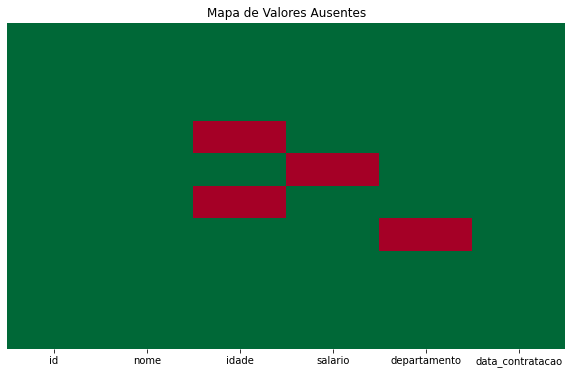

In [3]:
# Verificando valores ausentes
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

# Visualização dos valores ausentes
plt.figure(figsize=(10, 6))
sns.heatmap(df.notna(), yticklabels=False, cbar=False, cmap='RdYlGn')
plt.title('Mapa de Valores Ausentes')
plt.show()

### 3 - Tratamento de valores ausentes

In [4]:
# 1. Removendo linhas com valores ausentes
df_removido = df.dropna()
print("\nDataFrame após remover linhas com valores ausentes:")
print(df_removido.shape)

# 2. Preenchendo com média
df_preenchido_media = df.copy()
df_preenchido_media['idade'].fillna(df_preenchido_media['idade'].mean(), inplace=True)
df_preenchido_media['salario'].fillna(df_preenchido_media['salario'].mean(), inplace=True)

# 3. Preenchendo com valor específico
df_preenchido_especifico = df.copy()
df_preenchido_especifico['departamento'].fillna('Não especificado', inplace=True)

print("\nExemplo de preenchimento com valor específico:")
print(df_preenchido_especifico['departamento'].value_counts())


DataFrame após remover linhas com valores ausentes:
(6, 6)

Exemplo de preenchimento com valor específico:
TI                  5
Marketing           3
Vendas              1
Não especificado    1
Name: departamento, dtype: int64


### 4 - Identificando duplicados

In [6]:
# Verificando duplicatas
print("\nNúmero de linhas duplicadas:", df.duplicated().sum())

# Mostrando as linhas duplicadas
print("\nLinhas duplicadas:")
print(df[df.duplicated(keep=False)].sort_values('id'))


Número de linhas duplicadas: 0

Linhas duplicadas:
Empty DataFrame
Columns: [id, nome, idade, salario, departamento, data_contratacao]
Index: []


### 5 - Removendo duplicados

In [8]:
# Removendo duplicatas
df_sem_duplicatas = df.drop_duplicates()

print("Formato original:", df.shape)
print("Formato após remoção de duplicatas:", df_sem_duplicatas.shape)

print("\nDataFrame após remoção de duplicatas:")
df_sem_duplicatas

Formato original: (10, 6)
Formato após remoção de duplicatas: (10, 6)

DataFrame após remoção de duplicatas:


,id,nome,idade,salario,departamento,data_contratacao
0,1,João Silva,32.0,4500.0,TI,2020-01-15
1,2,Maria Santos,28.0,3800.0,Marketing,2019-06-20
2,3,João Silva,32.0,4500.0,TI,2020-01-15
3,4,Ana Oliveira,NaN,4200.0,TI,2021-03-10
4,5,Pedro Costa,45.0,NaN,Vendas,2018-11-05
5,6,Ana Oliveira,NaN,4200.0,TI,2021-03-10
6,7,Carla Lima,35.0,5100.0,NaN,2022-02-28
7,8,Marcos Santos,41.0,4800.0,Marketing,2020-09-15
8,9,Lucia Ferreira,29.0,3900.0,TI,2021-07-01
9,10,Marcos Santos,41.0,4800.0,Marketing,2020-09-15


### 6 - Resumo

In [9]:
def limpar_dados(df):
    # Criar uma cópia do DataFrame
    df_limpo = df.copy()
    
    # Remover duplicatas
    df_limpo = df_limpo.drop_duplicates()
    
    # Preencher valores ausentes
    df_limpo['idade'].fillna(df_limpo['idade'].mean(), inplace=True)
    df_limpo['salario'].fillna(df_limpo['salario'].mean(), inplace=True)
    df_limpo['departamento'].fillna('NÃO ESPECIFICADO', inplace=True)
    
    # Limpeza de strings
    df_limpo['nome'] = df_limpo['nome'].str.strip()
    df_limpo['departamento'] = df_limpo['departamento'].str.strip().str.upper()

    
    
    return df_limpo

# Aplicando a função de limpeza
df_final = limpar_dados(df)

print("\nDataFrame após todas as operações de limpeza:")
df_final


DataFrame após todas as operações de limpeza:


,id,nome,idade,salario,departamento,data_contratacao
0,1,João Silva,32.000,4500.000000,TI,2020-01-15
1,2,Maria Santos,28.000,3800.000000,MARKETING,2019-06-20
2,3,João Silva,32.000,4500.000000,TI,2020-01-15
3,4,Ana Oliveira,35.375,4200.000000,TI,2021-03-10
4,5,Pedro Costa,45.000,4422.222222,VENDAS,2018-11-05
5,6,Ana Oliveira,35.375,4200.000000,TI,2021-03-10
6,7,Carla Lima,35.000,5100.000000,NÃO ESPECIFICADO,2022-02-28
7,8,Marcos Santos,41.000,4800.000000,MARKETING,2020-09-15
8,9,Lucia Ferreira,29.000,3900.000000,TI,2021-07-01
9,10,Marcos Santos,41.000,4800.000000,MARKETING,2020-09-15
